In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import os 
nltk.download('stopwords')

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import linear_kernel
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package stopwords to /home/sy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
LOCATION = ['Hanoi', 'Danang', 'Hoi An', 'Ninh Binh', 'Ho Chi Minh City', 'Nha Trang', 'Phú Quốc', 'Hue', 'Da Lat', 'Vung Tau']

In [3]:
hotel_details = pd.read_csv("data/hotel_details/hotel_details.csv")
ratings = pd.read_csv("data/hotel_ratings/hotel_ratings.csv")

In [4]:
ratings = ratings.merge(
    hotel_details[['hotel_id','hotel_url','hotel_location', 'hotel_name','hotel_description','hotel_address']],
    left_on='HotelID',
    right_on='hotel_id',
    how='left'
)
ratings

,HotelID,UserID,User,Country,Review,Rating,hotel_id,hotel_url,hotel_location,hotel_name,hotel_description,hotel_address
0,2,3,Lê,Vietnam,Exceptional,10.0,2,https://www.booking.com/hotel/vn/can-ho-2-phon...,Vung Tau,Căn hộ 2 Phòng ngủ Tháp Tam Thắng,Beachfront Location: Căn hộ 2 Phòng ngủ Tháp T...,"Lihi Homestay, 790900 Vung Tau, Vietnam"
1,2,17,Bánh,Vietnam,Exceptional,10.0,2,https://www.booking.com/hotel/vn/can-ho-2-phon...,Vung Tau,Căn hộ 2 Phòng ngủ Tháp Tam Thắng,Beachfront Location: Căn hộ 2 Phòng ngủ Tháp T...,"Lihi Homestay, 790900 Vung Tau, Vietnam"
2,2,6,Kỳ,Vietnam,Ổn nếu biết cách khắc phục.,7.0,2,https://www.booking.com/hotel/vn/can-ho-2-phon...,Vung Tau,Căn hộ 2 Phòng ngủ Tháp Tam Thắng,Beachfront Location: Căn hộ 2 Phòng ngủ Tháp T...,"Lihi Homestay, 790900 Vung Tau, Vietnam"
3,2,15,Ngọc,Vietnam,Exceptional,10.0,2,https://www.booking.com/hotel/vn/can-ho-2-phon...,Vung Tau,Căn hộ 2 Phòng ngủ Tháp Tam Thắng,Beachfront Location: Căn hộ 2 Phòng ngủ Tháp T...,"Lihi Homestay, 790900 Vung Tau, Vietnam"
4,3,7,Công,Vietnam,Ok,9.0,3,https://www.booking.com/hotel/vn/khach-san-lam...,Hanoi,Lam Anh Hotel 8 Ngoại Giao Đoàn BT3-10,Comfortable Accommodations: Lam Anh Hotel 8 Ng...,"BT3-10, Khu biệt thự, khu đoàn ngoại giao, phư..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1474574,8165,216,Diego,Brazil,Very Good,8.0,8165,https://www.booking.com/hotel/vn/qua-cam-tim-h...,Hoi An,Qua Cam Tim Homestay,Comfortable Accommodations: Qua Cam Tim Homest...,"92 Nguyen Phuc Tan Street, Cam Pho Ward, Minh ..."
1474575,8165,333,Martina,Italy,Very Good,8.0,8165,https://www.booking.com/hotel/vn/qua-cam-tim-h...,Hoi An,Qua Cam Tim Homestay,Comfortable Accommodations: Qua Cam Tim Homest...,"92 Nguyen Phuc Tan Street, Cam Pho Ward, Minh ..."
1474576,8165,75577,Reynald,France,Very Good,8.0,8165,https://www.booking.com/hotel/vn/qua-cam-tim-h...,Hoi An,Qua Cam Tim Homestay,Comfortable Accommodations: Qua Cam Tim Homest...,"92 Nguyen Phuc Tan Street, Cam Pho Ward, Minh ..."
1474577,8165,131478,Ivarsson,Sweden,Very Good,8.0,8165,https://www.booking.com/hotel/vn/qua-cam-tim-h...,Hoi An,Qua Cam Tim Homestay,Comfortable Accommodations: Qua Cam Tim Homest...,"92 Nguyen Phuc Tan Street, Cam Pho Ward, Minh ..."


In [ ]:
ratings.to_parquet('data/data_merge.parquet')

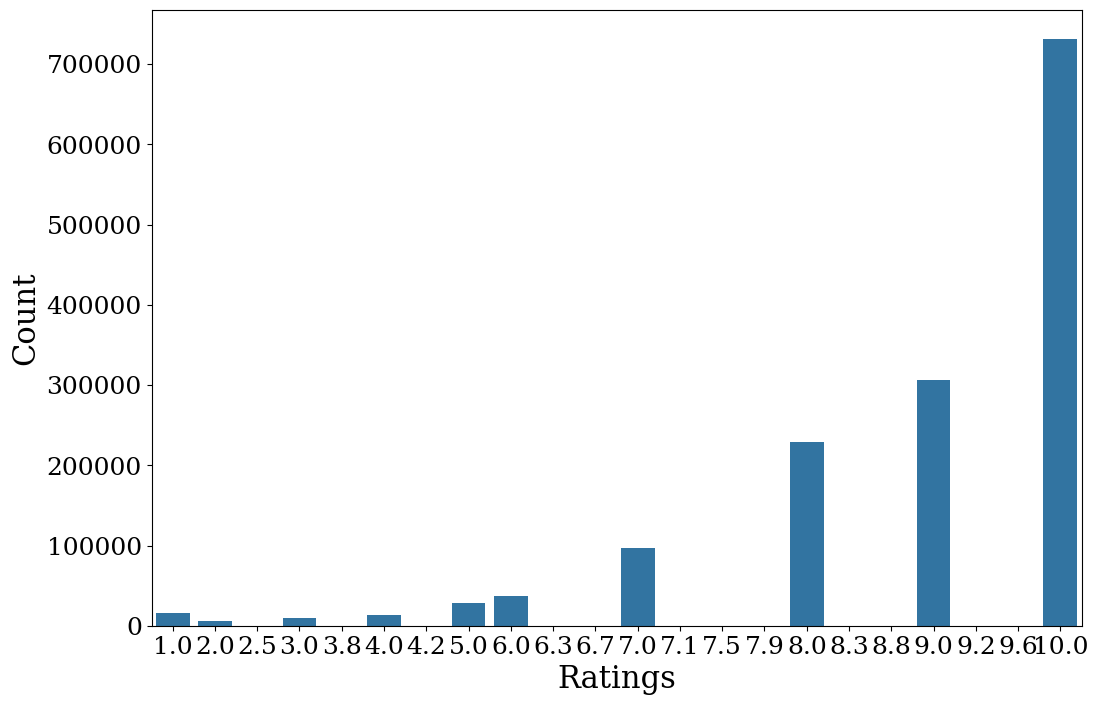

In [6]:
plt.figure(figsize=(12, 8))
sns.countplot(x=ratings["Rating"])

plt.xlabel('Ratings', fontsize=22, fontfamily='serif')
plt.ylabel('Count', fontsize=22, fontfamily='serif')

plt.xticks(fontsize=18, fontfamily='serif')
plt.yticks(fontsize=18, fontfamily='serif')

plt.show()

In [7]:
ratings_user = pd.read_parquet('data/train_test/total_by_user.parquet')
ratings_user

,HotelID,UserID,User,Country,Review,Rating,Location,hotel_name,hotel_description
0,2,3,Lê,Vietnam,Exceptional,10.0,Vung Tau,Căn hộ 2 Phòng ngủ Tháp Tam Thắng,Beachfront Location: Căn hộ 2 Phòng ngủ Tháp T...
1,2,15,Ngọc,Vietnam,Exceptional,10.0,Vung Tau,Căn hộ 2 Phòng ngủ Tháp Tam Thắng,Beachfront Location: Căn hộ 2 Phòng ngủ Tháp T...
2,3,14,Thanh,Vietnam,Exceptional,10.0,Hanoi,Lam Anh Hotel 8 Ngoại Giao Đoàn BT3-10,Comfortable Accommodations: Lam Anh Hotel 8 Ng...
3,3,5,Will,Vietnam,Exceptional,10.0,Hanoi,Lam Anh Hotel 8 Ngoại Giao Đoàn BT3-10,Comfortable Accommodations: Lam Anh Hotel 8 Ng...
4,4,2463,Megan,Australia,Great location,8.0,Da Lat,Guesthouse Thắng Linh,Comfortable Accommodations: Guest house Thắng ...
...,...,...,...,...,...,...,...,...,...
457399,8165,690,Simon,Germany,Exceptional,10.0,Hoi An,Qua Cam Tim Homestay,Comfortable Accommodations: Qua Cam Tim Homest...
457400,8165,3710,Ralf,Germany,Wonderful,9.0,Hoi An,Qua Cam Tim Homestay,Comfortable Accommodations: Qua Cam Tim Homest...
457401,8165,19,Manuel,Spain,Wonderful,9.0,Hoi An,Qua Cam Tim Homestay,Comfortable Accommodations: Qua Cam Tim Homest...
457402,8165,3154,Tina,Germany,Very Good,8.0,Hoi An,Qua Cam Tim Homestay,Comfortable Accommodations: Qua Cam Tim Homest...


In [8]:
ratings_test_user = pd.read_parquet('data/train_test/test_by_user.parquet')
ratings_test_user

,HotelID,UserID,User,Country,Review,Rating,Location,hotel_name,hotel_description
0,7957,1,Sandra,France,Exceptional,10.0,Da Lat,September Garden Homestay,Elegant Garden Setting: September Garden Homes...
1,4062,1,Sandra,United States,Great place in Da Lat!,10.0,Da Lat,The Note Dalat,Comfortable Accommodations: The Note Dalat in ...
2,7410,1,Sandra,Canada,Exceptional,10.0,Da Lat,Sweet Lavender Hotel,Comfortable Accommodations: Sweet Lavender Hot...
3,4883,1,Sandra,Australia,Exceptional,10.0,Da Lat,Le Macaron City Center - Boutique Hotel Đà Lạt,Comfortable Accommodations: Le Macaron City Ce...
4,2643,1,Sandra,Germany,Uneingeschränkt zu empfehlen!,10.0,Da Lat,Khách sạn Pine Hill Hotel Dalat,Comfortable Accommodations: Khách sạn Pine Hil...
...,...,...,...,...,...,...,...,...,...
34275,3428,11656,Thịnh,Vietnam,Wonderful,9.0,Vung Tau,Havilla The Song Apartment Near Beach Vung Tau,Elegant Accommodations: Havilla The Song Apart...
34276,7206,11656,Thịnh,Vietnam,Very Good,8.0,Vung Tau,The Song Luxury Vung Tau - Khang Apartment 1,Prime Beachfront Location: The Song Luxury Vun...
34277,6964,11656,Thịnh,Vietnam,Wonderful,9.0,Vung Tau,Milan Corner Hotel,Comfortable Accommodations: Milan Corner Hotel...
34278,6528,11656,Thịnh,Vietnam,Exceptional,10.0,Vung Tau,The Malibu Hotel,"Housed in a prominent and modern, gray skyscra..."


In [9]:
ratings_test_item = pd.read_parquet('data/train_test/test_by_item.parquet')
ratings_test_item

,HotelID,UserID,User,Country,Review,Rating,Location,hotel_name,hotel_description
0,1,179,Coral,United Kingdom,did the job,6.0,Nha Trang,BN Boutique Nha Trang Beach,Prime Beachfront Location: BN Boutique Nha Tra...
1,1,138,Nguyen,Vietnam,Unhappy,6.0,Nha Trang,BN Boutique Nha Trang Beach,Prime Beachfront Location: BN Boutique Nha Tra...
2,1,154,Byron,United Kingdom,There must be better options,3.0,Nha Trang,BN Boutique Nha Trang Beach,Prime Beachfront Location: BN Boutique Nha Tra...
3,4,3945,Sebastian,Germany,Very Good,8.0,Da Lat,Guesthouse Thắng Linh,Comfortable Accommodations: Guest house Thắng ...
4,4,2767,Ana,Spain,Exceptional,10.0,Da Lat,Guesthouse Thắng Linh,Comfortable Accommodations: Guest house Thắng ...
...,...,...,...,...,...,...,...,...,...
16552,8164,620,Trúc,Vietnam,Wonderful,9.0,Vung Tau,Ham Homestay,Comfortable Accommodations: Ham Homestay in Vu...
16553,8164,252,Kim,Vietnam,Wonderful,9.0,Vung Tau,Ham Homestay,Comfortable Accommodations: Ham Homestay in Vu...
16554,8165,3017,Tiago,Portugal,Wonderful,9.0,Hoi An,Qua Cam Tim Homestay,Comfortable Accommodations: Qua Cam Tim Homest...
16555,8165,540,Dana,Germany,Exceptional,10.0,Hoi An,Qua Cam Tim Homestay,Comfortable Accommodations: Qua Cam Tim Homest...


In [10]:
ratings_test_cb = pd.read_parquet('data/train_test/test_cb.parquet')
ratings_test_cb

,HotelID,UserID,User,Country,Review,Rating,Location,hotel_name,hotel_description
0,76,1,Sandra,Italy,Super!,10.0,Da Lat,Khách Sạn The Pine Scent,Comfortable Accommodations: Khách Sạn The Pine...
1,811,1,Sandra,Australia,"Great location, nice staff, bit noisy and cook...",7.0,Da Lat,Hotel Làng Kò Hơ,Comfortable Accommodations: Hotel Làng Kò Hơ i...
2,1231,1,Sandra,Canada,Exceptional,10.0,Da Lat,Le Tuan Minh Hotel,Comfortable Accommodations: Le Tuan Minh Hotel...
3,1241,1,Sandra,France,Very Good,8.0,Da Lat,Ngọc Khánh Hotel,Comfortable Accommodations: Ngọc Khánh Hotel i...
4,1273,1,Sandra,Germany,Exceptional,10.0,Da Lat,Khách sạn Thung Lũng Kim Khuê - Đà Lạt,Comfortable Accommodations: Khách sạn Thung Lũ...
...,...,...,...,...,...,...,...,...,...
92520,1417,23884,Khiêm,Vietnam,Good,7.0,Vung Tau,Amora Hotel & Apartment,Comfortable Accommodations: Amora Hotel & Apar...
92521,1799,23884,Khiêm,Vietnam,Wonderful,9.0,Vung Tau,The Song Apartment 5 Stars - Villa Biển Vung T...,Prime Beachfront Location: The Song Apartment ...
92522,3468,23884,Khiêm,Vietnam,Wonderful,9.0,Vung Tau,Le Sable Homestay,Comfortable Accommodations: Le Sable Homestay ...
92523,4138,23884,Khiêm,Vietnam,Oke,7.0,Vung Tau,Newinn vũng tàu2016,Comfortable Accommodations: Newinn vũng tàu201...


In [11]:
hotels_merge = pd.read_parquet('data/train_test/data_cb_merge.parquet')
hotels_merge

,UserID,Location,Name Hotel,Descriptions
0,1,Da Lat,"Anh Quan Khoi Hotel,Minh Chien Hotel,9Trip Sta...",Comfortable Accommodations: Anh Quan Khoi Hote...
1,1,Danang,"Century Hotel Da Nang,Mộc Nhiên Hotel Da Nang,...",Comfortable Accommodations: Century Hotel Da N...
2,1,Hanoi,"Casa Valentina Hanoi Hotel,Mövenpick Living We...",Comfortable Accommodations: Casa Valentina Han...
3,1,Ho Chi Minh City,"Sheraton Saigon Grand Opera Hotel,Spacious 4BR...",Prime City Center Location: Sheraton Saigon Gr...
4,1,Hoi An,Grand Sunrise Palace Hoi An- A Luxury Indochin...,Elegant Accommodations: Grand Sunrise Palace H...
...,...,...,...,...
18500,41191,Danang,"Waikiki Beach Hotel Da Nang,Tashi Oasis Hotel ...",Beachfront Location: Waikiki Beach Hotel Da Na...
18501,42080,Hanoi,"Minerva Premium Hotel,La Siesta Premium Lakesi...",Comfortable Accommodations: Minerva Premium Ho...
18502,42328,Hoi An,"The Sun Homestay,iHome Hoi An,Cam Nam Homestay...",Prime Location: The Sun Homestay in Hoi An off...
18503,54611,Hanoi,"Myrcella Urban Apartment,Label6 To Ngoc Van - ...",Comfortable Accommodations: Myrcella Urban Apa...


# **Collaborative Filtering**

## **Based on User**

### **Modeling**

In [12]:
ratings_user.info()

<class 'pandas.DataFrame'>
RangeIndex: 457404 entries, 0 to 457403
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   HotelID            457404 non-null  int32   
 1   UserID             457404 non-null  int32   
 2   User               457404 non-null  str     
 3   Country            456892 non-null  str     
 4   Review             457211 non-null  str     
 5   Rating             457404 non-null  float32 
 6   Location           457404 non-null  category
 7   hotel_name         457404 non-null  str     
 8   hotel_description  457404 non-null  str     
dtypes: category(1), float32(1), int32(2), str(5)
memory usage: 424.4 MB


In [13]:
ratings_user_df = ratings_user.pivot_table(
    index="UserID",
    columns="HotelID",
    values="Rating"
)
ratings_user_df

HotelID,1,2,3,4,5,6,8,9,10,12,...,8154,8155,8156,8157,8158,8159,8161,8162,8164,8165
UserID,,,,,,,,,,,,,,,,,,,,,
1,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,9.0,NaN,NaN,NaN,10.0,NaN,NaN,10.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN,10.0
3,9.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,10.0,10.0,10.0,10.0,NaN,NaN,NaN,9.0
5,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,NaN,NaN


In [14]:
global_mean = ratings_user["Rating"].mean()
user_mean = ratings_user_df.mean(axis=1)

ratings_centered = ratings_user_df.sub(user_mean, axis=0)
ratings_centered = ratings_centered.fillna(0)

In [15]:
user_similarity = cosine_similarity(ratings_centered)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=ratings_user_df.index,
    columns=ratings_user_df.index
)

In [16]:
def most_similar_user(user_id, k):

    if user_id not in user_similarity_df.index:
        return None

    return (
        user_similarity_df.loc[user_id]
        .drop(user_id)
        .nlargest(k)
    )

In [17]:
%%time
most_similar_user(200, 5)

CPU times: user 37.1 ms, sys: 1.02 ms, total: 38.1 ms
Wall time: 3.94 ms


UserID
2826     0.153604
11682    0.115270
5232     0.111527
2977     0.109647
2905     0.107872
Name: 200, dtype: float32

In [18]:
def get_recommendation_based_on_user(user_id, k, location):

    similar_users = most_similar_user(user_id, k)

    if similar_users is None:
        return None

    similar_users = similar_users[similar_users > 0]

    if len(similar_users) == 0:
        return None

    neighbor_ratings = ratings_user_df.loc[similar_users.index]

    neighbor_mean = user_mean.loc[similar_users.index]

    neighbor_centered = neighbor_ratings.sub(neighbor_mean, axis=0)

    sim_scores = similar_users.values.reshape(-1,1)

    weighted = neighbor_centered.mul(sim_scores)

    score = weighted.sum(axis=0)

    sim_sum = np.abs(sim_scores).sum()

    predicted = user_mean[user_id] + (score / sim_sum)

    user_seen = ratings_user_df.loc[user_id]

    predicted = predicted[user_seen.isna()]

    hotels_loc = set(
        ratings_user[ratings_user.Location == location]["HotelID"]
    )

    predicted = predicted[predicted.index.isin(hotels_loc)]

    return predicted.sort_values(ascending=False)

In [19]:
%%time
get_recommendation_based_on_user(3152, 10, LOCATION[6])

CPU times: user 56 ms, sys: 108 ms, total: 164 ms
Wall time: 164 ms


HotelID
6354    9.258601
52      9.219069
7611    9.168512
5642    9.137172
487     9.135515
          ...   
7216    8.042379
1895    7.990735
7059    7.916153
6749    7.876121
4618    7.787629
Length: 706, dtype: float32

### **Evaluation**

In [20]:
def predict_for_test_user(test_df, k):

    y_pred = []
    cache = {}

    print(f"Predicting {len(test_df)} samples")

    for _, row in test_df.iterrows():

        user = row["UserID"]
        hotel = row["HotelID"]
        location = row["Location"]

        key = (user, location)

        if key not in cache:
            cache[key] = get_recommendation_based_on_user(user, k, location)

        rec = cache[key]

        if rec is None:
            y_pred.append(global_mean)

        elif hotel in rec.index:
            y_pred.append(rec[hotel])

        else:
            y_pred.append(global_mean)

    return y_pred

In [21]:
y_pred = predict_for_test_user(ratings_test_user, k=20)

Predicting 34280 samples


In [22]:
y_true = ratings_test_user["Rating"]

In [23]:
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
nmae = mae / 10

In [24]:
print("USER BASED CF")
print("MAE:", mae)
print("RMSE:", rmse)
print("NMAE:", nmae)

USER BASED CF
MAE: 1.1870888471603394
RMSE: 1.6682385979023655
NMAE: 0.11870888471603394


## **Based on Item**

### **Modeling**

In [25]:
ratings_item_df = ratings_centered.T

item_similarity = cosine_similarity(ratings_item_df)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=ratings_item_df.index,
    columns=ratings_item_df.index
)

In [26]:
item_topk = {
    item: item_similarity_df.loc[item].drop(item).nlargest(20)
    for item in item_similarity_df.index
}

In [27]:
def get_recommendation_based_on_item(user_id, k, location):

    if user_id not in ratings_user_df.index:
        return None

    user_ratings = ratings_user_df.loc[user_id]

    rated_items = user_ratings.dropna()

    if len(rated_items) == 0:
        return None

    scores = {}
    sim_sums = {}

    for hotel_id, rating in rated_items.items():

        similar_items = item_topk.get(hotel_id)

        if similar_items is None:
            continue

        for sim_hotel, sim_score in similar_items.items():

            if sim_hotel in rated_items.index:
                continue

            scores.setdefault(sim_hotel,0)
            sim_sums.setdefault(sim_hotel,0)

            scores[sim_hotel] += sim_score * rating
            sim_sums[sim_hotel] += abs(sim_score)

    predicted = {
        h: scores[h]/sim_sums[h]
        for h in scores if sim_sums[h] != 0
    }

    predicted = pd.Series(predicted)

    hotels_loc = set(
        ratings_user[ratings_user.Location == location]["HotelID"]
    )

    predicted = predicted[predicted.index.isin(hotels_loc)]

    return predicted.sort_values(ascending=False)

### **Evaluation**

In [28]:
def predict_for_test_item(test_df, k):

    y_pred = []
    cache = {}

    print(f"Predicting {len(test_df)} samples")

    for _, row in test_df.iterrows():

        user = row["UserID"]
        hotel = row["HotelID"]
        location = row["Location"]

        key = (user, location)

        if key not in cache:
            cache[key] = get_recommendation_based_on_item(user,k,location)

        rec = cache[key]

        if rec is None:
            y_pred.append(global_mean)

        elif hotel in rec.index:
            y_pred.append(rec[hotel])

        else:
            y_pred.append(global_mean)

    return y_pred

In [29]:
y_pred = predict_for_test_item(ratings_test_item,20)

Predicting 16557 samples


In [30]:
y_true = ratings_test_item["Rating"]

In [31]:
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
nmae = mae / 10

In [32]:
print("ITEM BASED CF")
print("MAE:", mae)
print("RMSE:", rmse)
print("NMAE:", nmae)

ITEM BASED CF
MAE: 1.3638644218444824
RMSE: 1.9892626665418502
NMAE: 0.13638644218444823


## **Content-based Filtering**

In [33]:
ratings

,HotelID,UserID,User,Country,Review,Rating,hotel_id,hotel_url,hotel_location,hotel_name,hotel_description,hotel_address
0,2,3,Lê,Vietnam,Exceptional,10.0,2,https://www.booking.com/hotel/vn/can-ho-2-phon...,Vung Tau,Căn hộ 2 Phòng ngủ Tháp Tam Thắng,Beachfront Location: Căn hộ 2 Phòng ngủ Tháp T...,"Lihi Homestay, 790900 Vung Tau, Vietnam"
1,2,17,Bánh,Vietnam,Exceptional,10.0,2,https://www.booking.com/hotel/vn/can-ho-2-phon...,Vung Tau,Căn hộ 2 Phòng ngủ Tháp Tam Thắng,Beachfront Location: Căn hộ 2 Phòng ngủ Tháp T...,"Lihi Homestay, 790900 Vung Tau, Vietnam"
2,2,6,Kỳ,Vietnam,Ổn nếu biết cách khắc phục.,7.0,2,https://www.booking.com/hotel/vn/can-ho-2-phon...,Vung Tau,Căn hộ 2 Phòng ngủ Tháp Tam Thắng,Beachfront Location: Căn hộ 2 Phòng ngủ Tháp T...,"Lihi Homestay, 790900 Vung Tau, Vietnam"
3,2,15,Ngọc,Vietnam,Exceptional,10.0,2,https://www.booking.com/hotel/vn/can-ho-2-phon...,Vung Tau,Căn hộ 2 Phòng ngủ Tháp Tam Thắng,Beachfront Location: Căn hộ 2 Phòng ngủ Tháp T...,"Lihi Homestay, 790900 Vung Tau, Vietnam"
4,3,7,Công,Vietnam,Ok,9.0,3,https://www.booking.com/hotel/vn/khach-san-lam...,Hanoi,Lam Anh Hotel 8 Ngoại Giao Đoàn BT3-10,Comfortable Accommodations: Lam Anh Hotel 8 Ng...,"BT3-10, Khu biệt thự, khu đoàn ngoại giao, phư..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1474574,8165,216,Diego,Brazil,Very Good,8.0,8165,https://www.booking.com/hotel/vn/qua-cam-tim-h...,Hoi An,Qua Cam Tim Homestay,Comfortable Accommodations: Qua Cam Tim Homest...,"92 Nguyen Phuc Tan Street, Cam Pho Ward, Minh ..."
1474575,8165,333,Martina,Italy,Very Good,8.0,8165,https://www.booking.com/hotel/vn/qua-cam-tim-h...,Hoi An,Qua Cam Tim Homestay,Comfortable Accommodations: Qua Cam Tim Homest...,"92 Nguyen Phuc Tan Street, Cam Pho Ward, Minh ..."
1474576,8165,75577,Reynald,France,Very Good,8.0,8165,https://www.booking.com/hotel/vn/qua-cam-tim-h...,Hoi An,Qua Cam Tim Homestay,Comfortable Accommodations: Qua Cam Tim Homest...,"92 Nguyen Phuc Tan Street, Cam Pho Ward, Minh ..."
1474577,8165,131478,Ivarsson,Sweden,Very Good,8.0,8165,https://www.booking.com/hotel/vn/qua-cam-tim-h...,Hoi An,Qua Cam Tim Homestay,Comfortable Accommodations: Qua Cam Tim Homest...,"92 Nguyen Phuc Tan Street, Cam Pho Ward, Minh ..."


### **Pre-processing data**

In [34]:
def load_stopwords(folder):

    stopwords=set()

    for f in os.listdir(folder):

        with open(os.path.join(folder,f),encoding="utf8") as file:

            for line in file:
                stopwords.add(line.strip().lower())

    return stopwords

In [35]:
stopwords = load_stopwords("data/stopwords")
stopwords

{'',
 'பின்னர்',
 'করিতে',
 'देखियो',
 'áng như',
 'càng hay',
 'اربعين',
 'εκεινα',
 '而况',
 'faremo',
 'đến xem',
 'chớ như',
 'jis',
 'гэтым',
 'ӯҳӯ',
 '宁可',
 'šeststotimi',
 'қорс',
 'iм',
 'teve',
 'мая',
 'நீ',
 'из',
 'арбаң-арбаң',
 'үшін',
 'cho rằng',
 'estás',
 '这样',
 'loại từ',
 'между',
 'welche',
 '那样',
 'tegen',
 'thêm',
 'rahi',
 'qua khỏi',
 'হলেও',
 '某',
 'lấy lý do',
 'trinajstemu',
 'ăla',
 'mint',
 'அந்தப்',
 'بكم',
 'таяу',
 'مثل',
 'mỗi người',
 'οὕτως',
 'thấp xuống',
 'же',
 'যিনি',
 '得',
 'tuon',
 'то даме ки',
 'उदाहरण',
 'iншых',
 '谁',
 '啥',
 'enkratne',
 'tolikšnem',
 'bất ngờ',
 'although',
 'nossos',
 'vào khoảng',
 'devetnajste',
 'sambil',
 'পেয়ে',
 'houveram',
 'iski',
 'to',
 'triintridesetem',
 'totul',
 'aqueles',
 'ءَ',
 'as',
 '共同',
 'thì phải',
 '考虑',
 'तेस्कारण',
 'desetem',
 'إن',
 'dvainšestdeset',
 'ҳар',
 'sedma',
 'dago',
 'কোটি',
 'dovolilo',
 'kolikor',
 'pertama',
 '唉',
 'bunga',
 'mở mang',
 'puri',
 'dagl',
 'асло',
 'inginkan',
 '也',


In [36]:
def preprocess_text(text):

    if not isinstance(text, str):
        return ""

    # lowercase
    text = text.lower()

    # remove punctuation
    text = re.sub(r"[^\w\s]", " ", text)

    # remove stopwords
    words = text.split()
    words = [w for w in words if w not in stopwords]

    return " ".join(words)

In [37]:
ratings['hotel_description'] = ratings['hotel_description'].apply(preprocess_text)

In [38]:
hotels = ratings[['HotelID', 'hotel_name', 'hotel_location', 'hotel_description', 'hotel_address']]
hotels = hotels.drop_duplicates().reset_index(drop=True)

In [39]:
hotels_merge['Descriptions'] = hotels_merge['Descriptions'].apply(preprocess_text)

In [40]:
list_user = hotels_merge['UserID'].unique()

In [41]:
list_user 

array([    1,     2,     3, ..., 42328, 54611, 61506],
      shape=(4045,), dtype=int32)

### **Modeling**

In [42]:
hotels_merge

,UserID,Location,Name Hotel,Descriptions
0,1,Da Lat,"Anh Quan Khoi Hotel,Minh Chien Hotel,9Trip Sta...",comfortable accommodations khoi lat offers fam...
1,1,Danang,"Century Hotel Da Nang,Mộc Nhiên Hotel Da Nang,...",comfortable accommodations century nang nang o...
2,1,Hanoi,"Casa Valentina Hanoi Hotel,Mövenpick Living We...",comfortable accommodations casa valentina hano...
3,1,Ho Chi Minh City,"Sheraton Saigon Grand Opera Hotel,Spacious 4BR...",prime city center location sheraton saigon gra...
4,1,Hoi An,Grand Sunrise Palace Hoi An- A Luxury Indochin...,elegant accommodations grand sunrise palace ho...
...,...,...,...,...
18500,41191,Danang,"Waikiki Beach Hotel Da Nang,Tashi Oasis Hotel ...",beachfront location waikiki beach nang nang of...
18501,42080,Hanoi,"Minerva Premium Hotel,La Siesta Premium Lakesi...",comfortable accommodations minerva premium han...
18502,42328,Hoi An,"The Sun Homestay,iHome Hoi An,Cam Nam Homestay...",prime location sun homestay hoi offers conveni...
18503,54611,Hanoi,"Myrcella Urban Apartment,Label6 To Ngoc Van - ...",comfortable accommodations myrcella urban apar...


In [43]:
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),
    min_df=2
)

desc_matrix = vectorizer.fit_transform(hotels["hotel_description"])

user_desc_matrix = vectorizer.transform(hotels_merge["Descriptions"])

cosine_sim = linear_kernel(user_desc_matrix, desc_matrix)

def get_recommendations_content_based_with_location(userid, location, k):

    idx_list = hotels_merge.index[hotels_merge['UserID'] == userid]

    if len(idx_list) == 0:
        return []

    idx = idx_list[0]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    hotel_indices = [i[0] for i in sim_scores]

    rec = hotels.iloc[hotel_indices]

    rec = rec[rec["hotel_location"]==location]

    return rec['hotel_name'].head(k).tolist()

In [44]:
%%time
ls = get_recommendations_content_based_with_location(1, LOCATION[0], 20)
ls

CPU times: user 7.93 ms, sys: 891 μs, total: 8.83 ms
Wall time: 8.48 ms


['Lam Anh Hotel 4 Ngoại Giao Đoàn BT6-19',
 'One Villa 4 Hotel',
 'San Palace Hotel & Rooftop',
 'Lam Anh Hotel 6 Ngoại Giao Đoàn BT4-10',
 'Gloud Hotel',
 'S79 Noi Bai Airport Boutique Hotel',
 'Marina Hotel Ha Noi',
 'Lam Anh Hotel 8 Ngoại Giao Đoàn BT3-10',
 'Wild Lotus Hotel Apartment 2',
 'Concon house',
 'Embrace Boutique Hanoi Hotel',
 'La Selva Premium Hotel',
 'Elegance Premium Hotel',
 'Narcissus Hotel & Apartment',
 'Tonkin House',
 'Hanoi Allure Hotel',
 '22Land Cosmos Hotel',
 'The Embassy Hotel Hanoi',
 'TrangTrang Classy Hotel',
 'Hanoi View Hotel & Travel']

In [45]:
%%time
num_hotels_cb = 25
  
list_content_based = []

for user in list_user:

    location = hotels_merge[hotels_merge['UserID']==user]['Location'].iloc[0]

    rec = get_recommendations_content_based_with_location(user, location, num_hotels_cb)

    list_content_based.append(rec)

CPU times: user 28.3 s, sys: 439 μs, total: 28.3 s
Wall time: 28.3 s


In [46]:
df_content_based = pd.DataFrame({
    'UserID': list_user,
    'List Recommendation': list_content_based
})
df_content_based

,UserID,List Recommendation
0,1,"[Dalat ECO Hotel 2, DALAT STREAM HOTEL-Khách s..."
1,2,"[DALAT STREAM HOTEL-Khách sạn đẹp Đà Lạt, THIE..."
2,3,"[688 Hotel Đà Lạt, Dalat ECO Hotel 2, DALAT ST..."
3,4,"[Solare De Monte Hotel & Spa, H Hôtel L'Art Ha..."
4,5,"[Moc Thach Hostel Dalat, Feliz Dalat Homestay,..."
...,...,...
4040,41191,"[Risemount Premier Resort Da Nang, Rosamia Da ..."
4041,42080,[Hanoi Center Silk Premium Hotel & Spa & Trave...
4042,42328,"[iHome Hoi An, Fivitel Hoi An Hotel, The Sun H..."
4043,54611,[Label6 To Ngoc Van - Crescendo Boutique Studi...


### **Evaluation**

In [47]:
%%time

# create dict: user -> list recommendation
user_rec_dict = dict(zip(df_content_based['UserID'], df_content_based['List Recommendation']))

check_userid = set()
count = 0

for _, row in ratings_test_cb.iterrows():

    user = row['UserID']
    hotel = row['hotel_name']

    if user in user_rec_dict and user not in check_userid:

        if hotel in user_rec_dict[user]:

            print(f'user = {user}, hotel = {hotel}, list hotels = {user_rec_dict[user]}')

            count += 1
            check_userid.add(user)

user = 7, hotel = AM Memory Central Hotel 2, list hotels = ['Dalat ECO Hotel 2', 'LE PHUONG Dalat', '688 Hotel Đà Lạt', 'DALAT STREAM HOTEL-Khách sạn đẹp Đà Lạt', 'Torino Hotel Dalat', 'Hanah Hotel Dalat', 'ALEX HOTEL Peony', 'Cattleya', 'THIEN AN GUEST HOUSE', 'Thanh Hùng Dalat Hotel', 'Mia House Dalat', 'Dalat Luxury Hotel', 'Carita Hotel', 'ARTIS Hotel Da Lat', 'Thanh Do Hotel', 'Khách sạn Hải Hoa Đà Lạt', 'Soda Hotel Đà Lạt', 'M Hotel Đà Lạt', 'Đông Đức Hostel Đà Lạt', 'Thanh Thanh 5 Dalat Hotel - KS Gần Chợ Đêm Giá Rẻ', 'Dalat Eco Hotel', 'H Flower Hotel Đà Lạt - An An Hotel cũ', 'AM Memory Central Hotel 2', 'Bống Stay', 'Tường Vy Dalat Central']
user = 9, hotel = Tường Vy Dalat Central, list hotels = ['Torino Hotel Dalat', 'Dalat ECO Hotel 2', 'DALAT STREAM HOTEL-Khách sạn đẹp Đà Lạt', 'The Note Dalat', 'Dan Chi Hotel', 'Gia Pham Hotel', 'Hostel-John Cafe and Beer', 'Tường Vy Dalat Central', 'Kim Oanh Orchids Hotel', 'LE PHUONG Dalat', 'Thanh Thanh 5 Dalat Hotel - KS Gần Chợ Đêm 

In [48]:
print(ratings_test_cb.columns)

Index(['HotelID', 'UserID', 'User', 'Country', 'Review', 'Rating', 'Location',
       'hotel_name', 'hotel_description'],
      dtype='str')


In [49]:
total_users = ratings_test_cb['UserID'].nunique()
accuracy = round((count / total_users) * 100, 2)

print(f"Accuracy = {accuracy}%")

Accuracy = 23.98%


In [50]:
df_content_based.head()

,UserID,List Recommendation
0,1,"[Dalat ECO Hotel 2, DALAT STREAM HOTEL-Khách s..."
1,2,"[DALAT STREAM HOTEL-Khách sạn đẹp Đà Lạt, THIE..."
2,3,"[688 Hotel Đà Lạt, Dalat ECO Hotel 2, DALAT ST..."
3,4,"[Solare De Monte Hotel & Spa, H Hôtel L'Art Ha..."
4,5,"[Moc Thach Hostel Dalat, Feliz Dalat Homestay,..."


In [51]:
df_content_based.to_csv(f'data/result_cb_{num_hotels_cb}.csv',index=False)